sdfzdfgdfgfghbfghbfghdrfgdfgzd

### MODELO REGRESIÓN LOGISTICA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
# To save models
import json
import pickle
# Feature Selection
from sklearn.feature_selection import f_classif, SelectKBest
# Modelado
from sklearn.linear_model import LogisticRegression
# Métricas
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

# Optimizar
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
# from tqdm import tqdm
import warnings
import zipfile
import os



In [3]:
# Lectura directa desde los archivos .zip
X_train = pd.read_csv('../data/processed/X_train_obj1-targetE.zip')
X_test = pd.read_csv('../data/processed/X_test_obj1-targetE.zip')
y_train = pd.read_csv('../data/processed/y_train_obj1-targetE.zip')
y_test = pd.read_csv('../data/processed/y_test_obj1-targetE.zip')

# Tip: Si el CSV tiene un nombre distinto dentro del zip, 
# pandas suele detectarlo automáticamente si solo hay uno.

In [4]:
X_train.shape

(496076, 19)

In [5]:
X_test.shape

(124019, 19)

In [6]:
y_train.shape

(496076, 1)

In [7]:
y_test.shape

(124019, 1)

Como se cargó estos datos desde archivos .csv, es muy probable que se haya colado una columna llamada Unnamed: 0 (que suele ser el índice antiguo). Antes de entrenar vamos a limpiar las X.

In [8]:
# Eliminar columna de índice sobrante si existe
for df_temp in [X_train, X_test]:
    if 'Unnamed: 0' in df_temp.columns:
        df_temp.drop(columns=['Unnamed: 0'], inplace=True)


In [9]:
# Reviso que no haya valores nulos con la nueva carga de archivo.

# Lista de tus variables cargadas
datasets = {"X_train": X_train,"X_test": X_test,"y_train": y_train, "y_test": y_test}

for nombre, df_actual in datasets.items():
    if df_actual is not None:
        total_nulos = df_actual.isnull().sum().sum() # Suma total de nulos en todo el dataframe
        print(f"{nombre}: {total_nulos} nulos encontrados.")
        
        # Si hay nulos, mostramos en qué columnas están
        if total_nulos > 0:
            df_actual.isnull().sum()[df_actual.isnull().sum() > 0]
            
    else:
        f"{nombre}: No está cargado (es None)."

X_train: 0 nulos encontrados.
X_test: 0 nulos encontrados.
y_train: 0 nulos encontrados.
y_test: 0 nulos encontrados.


In [10]:
model = LogisticRegression(penalty='l2', dual=False, tol=0.0001, C=1.0, fit_intercept=True, 
                                               intercept_scaling=1, class_weight=None, random_state=None, solver='lbfgs', max_iter=100, multi_class='auto',
                                            verbose=0 , warm_start = False , n_jobs = None , l1_ratio = None )


In [11]:
model.fit(X_train, y_train)

c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'auto'


In [12]:
y_pred = model.predict(X_test)
y_pred

array([1, 1, 1, ..., 1, 1, 1], shape=(124019,))

In [13]:
model_accuracy = accuracy_score(y_test, y_pred)
model_accuracy

0.5145985695740168

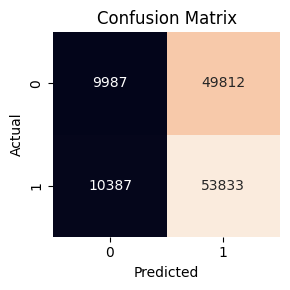

In [14]:
bank_cm = confusion_matrix(y_test, y_pred)

# Dibujaremos esta matriz para hacerla más visual
df_cm = pd.DataFrame(bank_cm)

plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt="d", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.tight_layout()
plt.show()

In [16]:
print(f"Precision: {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred, average='macro'):.4f}")

Precision: 0.5048
Recall:    0.5026
F1-Score:  0.4453


Precision: ¿Qué tan confiable es el modelo cuando dice que alguien pertenece a una clase? 
- 50.5%

Recall: ¿Qué tantos casos reales fue capaz de "atrapar" el modelo? 
- 50.2%

#### Hiperparametrización 
Con Random Search porque hay demasiados registros y con Grid Search daba error por falta de RAM.

In [17]:
 # 1. Definir el modelo base
log_reg = LogisticRegression(max_iter=1000)

param_grid = {'C': [0.01, 0.1, 1, 10, 100],'penalty': ['l1', 'l2'],'solver': ['liblinear', 'saga']}

random_search = RandomizedSearchCV(estimator=log_reg, param_distributions=param_grid, n_iter=10, cv=3, scoring='f1_macro', n_jobs=1)

random_search.fit(X_train, y_train)

f"Mejores parámetros:", random_search.best_params_

c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:140

('Mejores parámetros:', {'solver': 'liblinear', 'penalty': 'l2', 'C': 100})

--- REPORTE FINAL DEL MODELO OPTIMIZADO ---
              precision    recall  f1-score   support

           0       0.49      0.17      0.25     59799
           1       0.52      0.84      0.64     64220

    accuracy                           0.51    124019
   macro avg       0.51      0.50      0.45    124019
weighted avg       0.51      0.51      0.45    124019



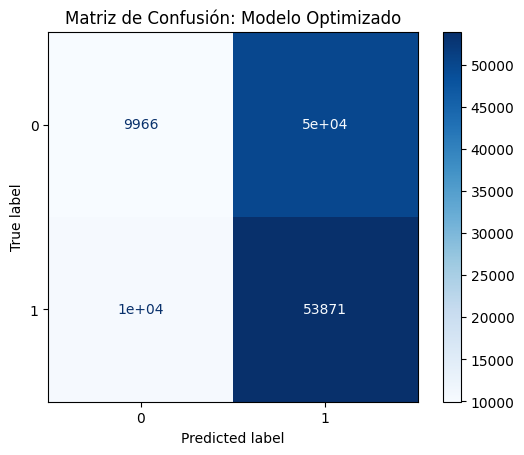

In [18]:
# 1. Obtener el mejor modelo
best_model = random_search.best_estimator_

# 2. Hacer predicciones con los datos de TEST
# (Asegúrate de que X_test esté escalado si escalaste X_train)
y_pred = best_model.predict(X_test)

# 3. Reporte de métricas
print("--- REPORTE FINAL DEL MODELO OPTIMIZADO ---")
print(classification_report(y_test, y_pred))

# 4. Matriz de Confusión visual
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title("Matriz de Confusión: Modelo Optimizado")
plt.show()

1. El modelo tiene un "Sesgo de Mayoría"
Observa el Recall:

Clase 1 (0.84): El modelo identifica correctamente al 84% de los casos positivos.

Clase 0 (0.17): El modelo solo identifica correctamente al 17% de los casos negativos.

Diagnóstico: El modelo está "apostando" casi siempre a la Clase 1. Al haber una ligera mayoría de Clase 1 en tus datos (64,220 vs 59,799), la Regresión Logística ha aprendido que predecir "1" la mayor parte del tiempo le da un 51% de aciertos sin esforzarse.

2. El problema de la Precisión
La Precision para ambas clases está estancada cerca del 0.50. Esto confirma que incluso cuando el modelo se arriesga a decir que algo es Clase 0, se equivoca la mitad de las veces. No hay una "señal" clara que el modelo esté captando.

3. ¿Por qué el Target Encoding no "salvó" el modelo?
Haber pasado de 400,000 columnas a 1 con Target Encoding fue el paso correcto para que el código funcionara, pero esto nos revela una verdad dolorosa sobre los datos: El 'Ticker' por sí solo no predice el futuro. El Target Encoding usa promedios históricos. Si el comportamiento pasado de un Ticker no se repite en el conjunto de test, el modelo falla.

In [19]:
# Ver cuántas columnas tienen varianza cero (son constantes)
constantes = [col for col in X_train.columns if X_train[col].std() == 0]
print(f"Columnas que no aportan nada (constantes): {len(constantes)}")

# Ver la correlación de las primeras columnas con y_train
# Esto te dará una idea de si hay señal en los datos
correlaciones = X_train.iloc[:, :100].corrwith(y_train)
print("Máxima correlación encontrada en las primeras 100 columnas:", correlaciones.abs().max())

Columnas que no aportan nada (constantes): 0
Máxima correlación encontrada en las primeras 100 columnas: nan


In [20]:
from sklearn.feature_selection import VarianceThreshold

# Eliminamos columnas donde el 99% de los valores sean iguales
selector = VarianceThreshold(threshold=(.99 * (1 - .99)))
X_train_sel = selector.fit_transform(X_train)
X_test_sel = selector.transform(X_test)

print(f"Columnas originales: {X_train.shape[1]}")
print(f"Columnas tras el filtro: {X_train_sel.shape[1]}")

Columnas originales: 19
Columnas tras el filtro: 19


## Conclusión:
Este modelo no me parece que de un buen resultado de predicción. 